<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Roll%2C%20R.%20(1977).%20A%20critique%20of%20the%20asset%20pricing%20theory%E2%80%99s%20tests%20Part%20I%20On%20past%20and%20potential%20testability%20of%20the%20theory/A_critique_of_the_asset_pricing_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(42)

# Simulate 1000 days of returns
n = 1000

# "True" market return (unobservable in reality)
true_market = np.random.normal(0.0005, 0.01, n)

# Create 5 assets with different betas
betas = [0.5, 1.0, 1.5, 0.8, 1.2]
assets = {}

for i, beta in enumerate(betas):
    noise = np.random.normal(0, 0.01, n)
    assets[f'Asset_{i+1}'] = beta * true_market + noise

df = pd.DataFrame(assets)
df['True_Market'] = true_market

In [ ]:
# Proxy 1: noisy version of true market
df['Proxy_1'] = df['True_Market'] + np.random.normal(0, 0.005, n)

# Proxy 2: equal-weighted portfolio of assets
df['Proxy_2'] = df[[col for col in df.columns if 'Asset' in col]].mean(axis=1)

In [ ]:
def run_capm(asset, market_proxy):
    X = sm.add_constant(market_proxy)
    model = sm.OLS(asset, X).fit()

    return {
        'alpha': model.params['const'],
        'beta': model.params[market_proxy.name],
        'R2': model.rsquared
    }

results = {}

for proxy in ['True_Market', 'Proxy_1', 'Proxy_2']:
    results[proxy] = {}
    for asset in df.columns[:5]:
        metrics = run_capm(df[asset], df[proxy])
        results[proxy][asset] = metrics

In [ ]:
for proxy, res in results.items():
    print(f"\n--- Using {proxy} ---")
    for asset, metrics in res.items():
        print(asset, metrics)


--- Using True_Market ---
Asset_1 {'alpha': np.float64(0.0007368941367102929), 'beta': np.float64(0.45884765873400596), 'R2': np.float64(0.16891323684870796)}
Asset_2 {'alpha': np.float64(4.2933342909864367e-05), 'beta': np.float64(1.0222246440951703), 'R2': np.float64(0.5089526514459979)}
Asset_3 {'alpha': np.float64(-0.00017750443973969907), 'beta': np.float64(1.4860270433162266), 'R2': np.float64(0.6674871533391276)}
Asset_4 {'alpha': np.float64(-0.00047078763657542683), 'beta': np.float64(0.7683425549798875), 'R2': np.float64(0.36522170577762725)}
Asset_5 {'alpha': np.float64(-0.0004632937575267958), 'beta': np.float64(1.194112037516121), 'R2': np.float64(0.5739799622436352)}

--- Using Proxy_1 ---
Asset_1 {'alpha': np.float64(0.0008546241684345176), 'beta': np.float64(0.3626872559317358), 'R2': np.float64(0.13081158436076445)}
Asset_2 {'alpha': np.float64(0.00031047613282760077), 'beta': np.float64(0.7984728439249091), 'R2': np.float64(0.3849106773780834)}
Asset_3 {'alpha': np.fl

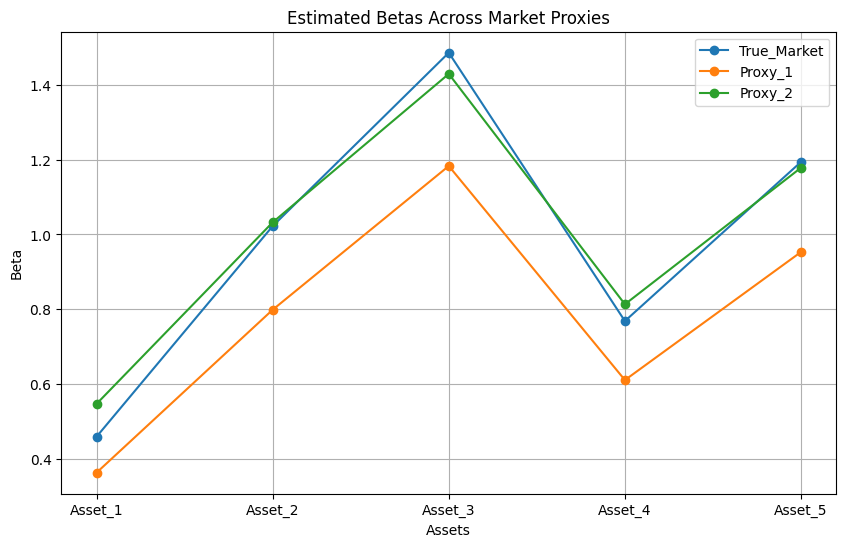

In [ ]:
import matplotlib.pyplot as plt

proxies = ['True_Market', 'Proxy_1', 'Proxy_2']
assets = df.columns[:5]

plt.figure(figsize=(10,6))

for proxy in proxies:
    betas = [results[proxy][asset]['beta'] for asset in assets]
    plt.plot(assets, betas, marker='o', label=proxy)

plt.title("Estimated Betas Across Market Proxies")
plt.xlabel("Assets")
plt.ylabel("Beta")
plt.legend()
plt.grid(True)
plt.show()

This graph illustrates how the estimated betas for each asset change depending on the market proxy used in the CAPM regression. Beta measures an asset’s sensitivity to market movements, and in theory, these estimates should be stable and reflect the true underlying risk of each asset. When the true market portfolio is used, the estimated betas should closely align with their actual values, showing consistency across assets. However, when different proxies are used instead, the beta estimates shift and become less reliable, varying noticeably across the same set of assets. This highlights that even a fundamental parameter like beta is sensitive to how the market is measured, reinforcing the insight from Richard Roll that empirical results in CAPM are heavily dependent on the choice of market proxy rather than purely reflecting the validity of the model itself.


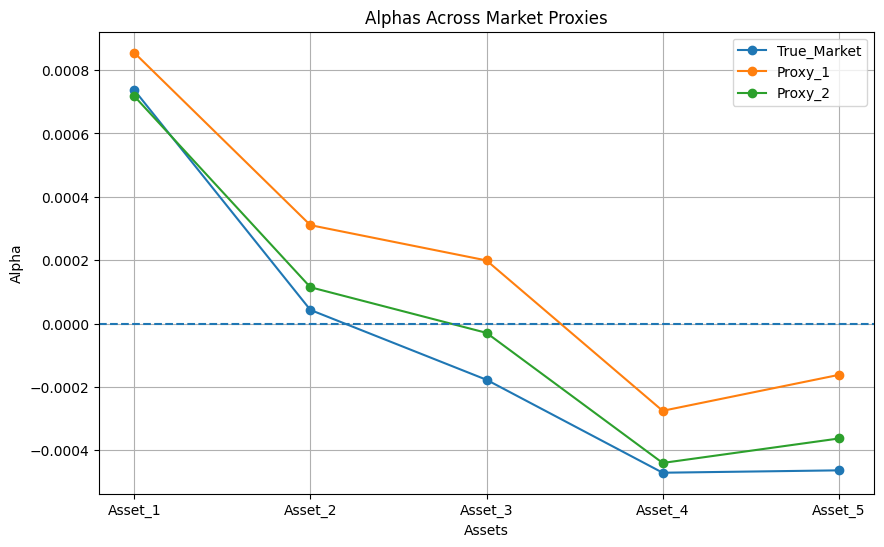

In [ ]:
plt.figure(figsize=(10,6))

for proxy in proxies:
    alphas = [results[proxy][asset]['alpha'] for asset in assets]
    plt.plot(assets, alphas, marker='o', label=proxy)

plt.axhline(0, linestyle='--')
plt.title("Alphas Across Market Proxies")
plt.xlabel("Assets")
plt.ylabel("Alpha")
plt.legend()
plt.grid(True)
plt.show()

This graph shows how the estimated alphas (intercepts) from the CAPM regressions vary across assets when different market proxies are used. In theory, CAPM predicts that all alphas should be equal to zero, meaning no asset consistently earns abnormal returns once risk is properly accounted for. When the true market portfolio is used, the alphas should cluster close to zero, aligning with the model’s prediction. However, when proxy variables are used instead, the alphas tend to deviate from zero and vary across assets, creating the appearance of mispricing or abnormal performance. This demonstrates that what looks like evidence against CAPM may simply be the result of using an imperfect proxy for the market, reinforcing the central argument made by Richard Roll that empirical tests of the model are inseparable from the choice of market portfolio.


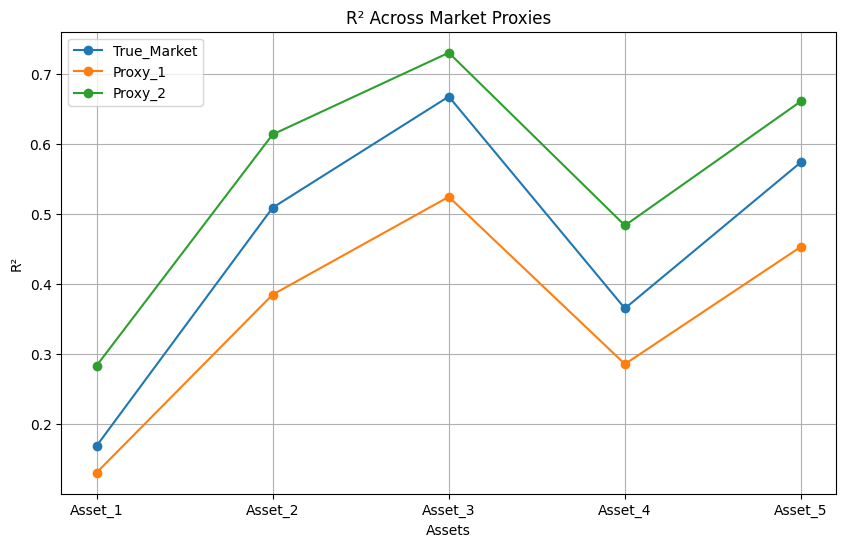

In [ ]:
plt.figure(figsize=(10,6))

for proxy in proxies:
    r2s = [results[proxy][asset]['R2'] for asset in assets]
    plt.plot(assets, r2s, marker='o', label=proxy)

plt.title("R² Across Market Proxies")
plt.xlabel("Assets")
plt.ylabel("R²")
plt.legend()
plt.grid(True)
plt.show()

This graph illustrates how well the CAPM explains asset returns when different market proxies are used, by plotting the R² values for each asset across the chosen proxies. The R² measures how much of an asset’s return variation is explained by the model, so higher values indicate a better fit. When the true market portfolio is used, the R² values should generally be higher, reflecting that the model is correctly specified and captures the underlying relationship. However, when proxy variables are used instead, the R² values tend to decline and vary more across assets, showing a weaker and less consistent fit. This demonstrates that the apparent explanatory power of CAPM depends heavily on the choice of market proxy, reinforcing the idea emphasized by Richard Roll that empirical tests of the model are inherently tied to the quality of the proxy rather than the validity of the theory itself.


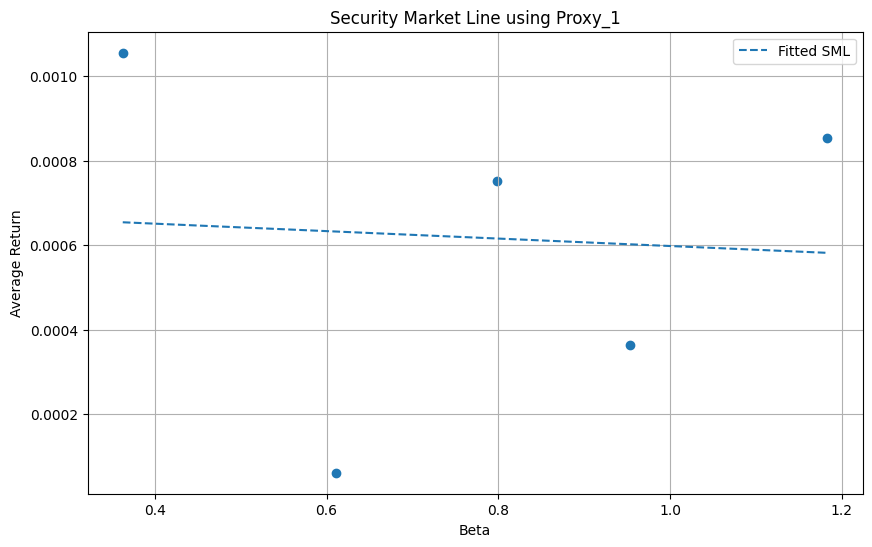

In [ ]:
import numpy as np

proxy = 'Proxy_1'  # try changing this!

betas = []
avg_returns = []

for asset in assets:
    betas.append(results[proxy][asset]['beta'])
    avg_returns.append(df[asset].mean())

plt.figure(figsize=(10,6))
plt.scatter(betas, avg_returns)

# Fit SML line
coef = np.polyfit(betas, avg_returns, 1)
x = np.linspace(min(betas), max(betas), 100)
y = coef[0]*x + coef[1]

plt.plot(x, y, linestyle='--', label='Fitted SML')

plt.title(f"Security Market Line using {proxy}")
plt.xlabel("Beta")
plt.ylabel("Average Return")
plt.legend()
plt.grid(True)
plt.show()

According to the Capital Asset Pricing Model (CAPM), expected returns should follow a linear relationship with beta, meaning that assets with higher systematic risk (beta) should earn proportionally higher returns. In the simulation, this relationship appears clearly when using the true market portfolio, producing a clean, well-aligned line. However, when a proxy is used instead, the relationship becomes distorted, with points appearing scattered and misaligned. This illustrates the core insight of Richard Roll, who argued that CAPM cannot be properly tested in practice because the true market portfolio is unobservable, so any empirical test inevitably depends on imperfect proxies.
